In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/dataset.csv")

In [4]:
df.head()

,Unnamed: 0,tesisat_no_id,il,ilce,gerilim_seviyesi,marka,model,abone_grubu,son_carpan_degeri,l1,l2,l3,v1,v2,v3,t0,ri,rc,load_profile_date
0,0,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,64.67,0.01,233.75,222.62,232.08,415005.784,1019.784,2030.002,2025-08-01 00:00:00.000
1,1,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,60.41,0.01,233.68,222.30,230.85,415009.205,1019.784,2030.013,2025-08-01 00:15:00.000
2,2,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,63.23,0.01,233.48,222.11,230.98,415012.559,1019.784,2030.021,2025-08-01 00:30:00.000
3,3,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,65.00,0.01,235.23,222.52,232.00,415015.917,1019.784,2030.033,2025-08-01 00:45:00.000
4,4,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,62.46,0.01,234.70,222.52,231.78,415019.282,1019.784,2030.043,2025-08-01 01:00:00.000


In [5]:
df.isnull().sum()

Unnamed: 0               0
tesisat_no_id            0
il                       0
ilce                     0
gerilim_seviyesi         0
marka                    0
model                    0
abone_grubu              0
son_carpan_degeri        0
l1                       0
l2                       0
l3                       0
v1                   75434
v2                   75434
v3                   75434
t0                       0
ri                   10240
rc                   10240
load_profile_date        0
dtype: int64

In [6]:
df["v1"] = df["v1"].fillna(df["v1"].mean())
df["v2"] = df["v2"].fillna(df["v2"].mean())
df["v3"] = df["v3"].fillna(df["v3"].mean())

df.isnull().sum()

Unnamed: 0               0
tesisat_no_id            0
il                       0
ilce                     0
gerilim_seviyesi         0
marka                    0
model                    0
abone_grubu              0
son_carpan_degeri        0
l1                       0
l2                       0
l3                       0
v1                       0
v2                       0
v3                       0
t0                       0
ri                   10240
rc                   10240
load_profile_date        0
dtype: int64

In [7]:
df["load_profile_date"] = pd.to_datetime(df["load_profile_date"])


df.dtypes

Unnamed: 0                    int64
tesisat_no_id                   str
il                              str
ilce                            str
gerilim_seviyesi                str
marka                           str
model                           str
abone_grubu                     str
son_carpan_degeri             int64
l1                          float64
l2                          float64
l3                          float64
v1                          float64
v2                          float64
v3                          float64
t0                          float64
ri                          float64
rc                          float64
load_profile_date    datetime64[us]
dtype: object

In [8]:
df = df.sort_values(["tesisat_no_id","load_profile_date"])
df["tuketim"] = df.groupby("tesisat_no_id")["t0"].diff()

df[["t0","tuketim"]].head(10)

,t0,tuketim
7263,3868.324,NaN
7264,3868.324,0.000
7265,3868.325,0.001
7266,3868.325,0.000
7267,3868.326,0.001
7268,3868.326,0.000
7269,3868.326,0.000
7270,3868.326,0.000
7271,3868.326,0.000
7272,3868.327,0.001


In [9]:
df = df[df["tuketim"] >= 0]

In [10]:
df["avg_current"] = (df["l1"] + df["l2"] + df["l3"]) / 3

anomali1 = df[(df["avg_current"] > 5) & (df["tuketim"] == 0)]


len(anomali1)

0

In [11]:
df["phase_imbalance"] = df[["l1","l2","l3"]].max(axis=1) - df[["l1","l2","l3"]].min(axis=1)
anomali2 = df[df["phase_imbalance"] > 50]


len(anomali2)

4279

In [12]:
anomali3 = df[df["tuketim"] > 500]

len(anomali3)

0

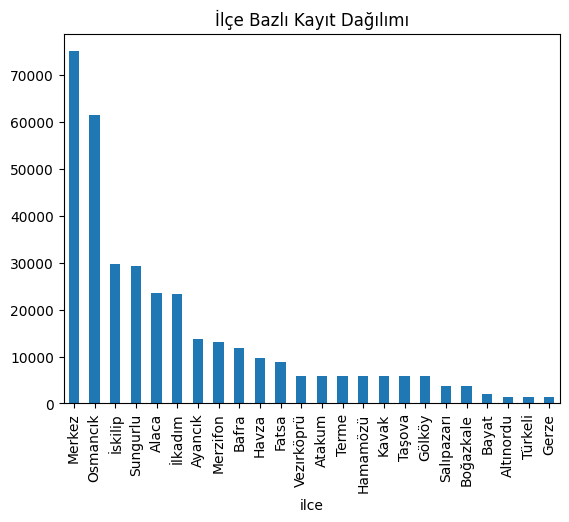

In [13]:
df["ilce"].value_counts().plot(kind="bar")

plt.title("İlçe Bazlı Kayıt Dağılımı")
plt.show()

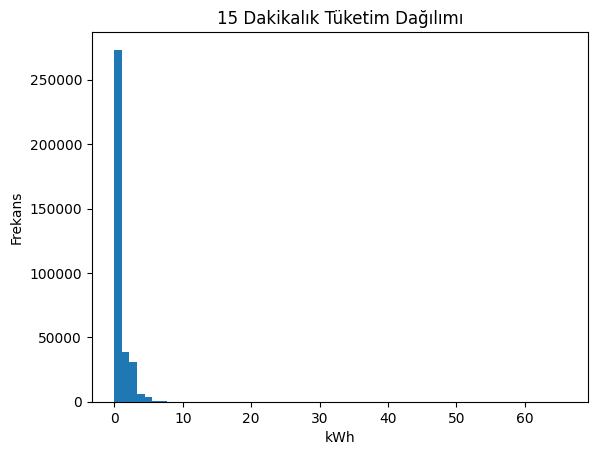

In [14]:
plt.hist(df["tuketim"], bins=60)

plt.title("15 Dakikalık Tüketim Dağılımı")
plt.xlabel("kWh")
plt.ylabel("Frekans")
plt.show()

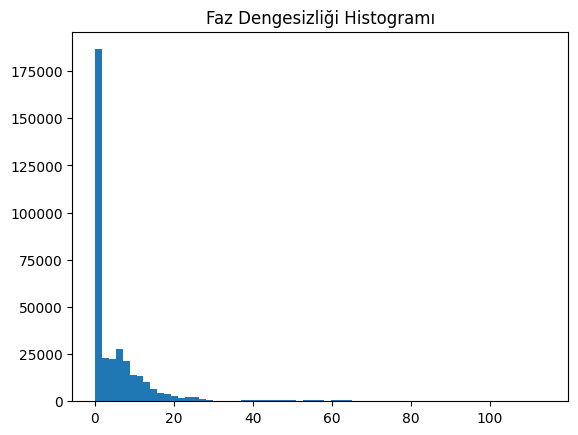

In [15]:
plt.hist(df["phase_imbalance"], bins=65)
plt.title("Faz Dengesizliği Histogramı")
plt.show()

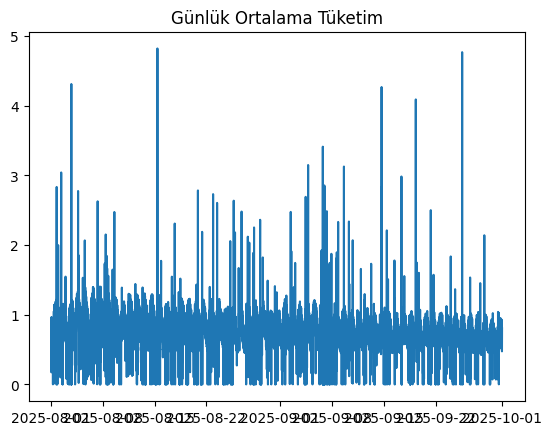

In [16]:
gunluk = df.groupby("load_profile_date")["tuketim"].mean()

plt.plot(gunluk)
plt.title("Günlük Ortalama Tüketim")
plt.show()

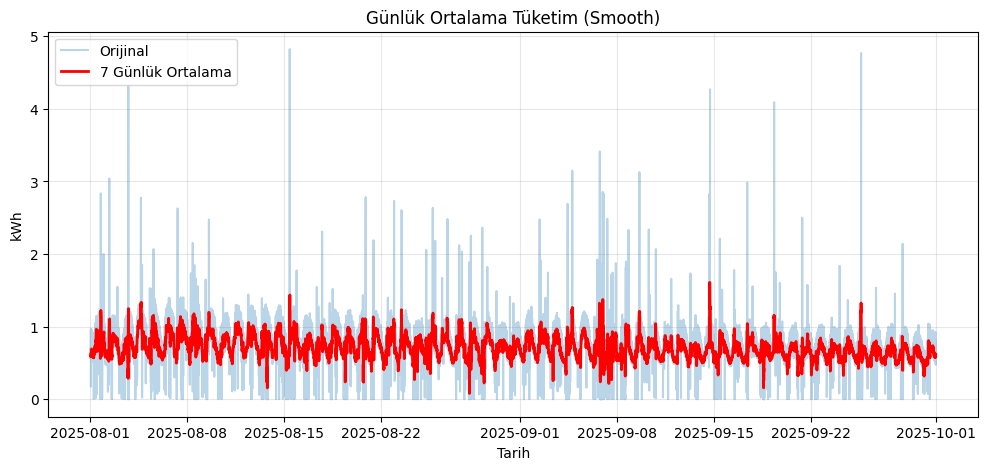

In [17]:
gunluk_smooth = gunluk.rolling(window=7, center=True).mean()

plt.figure(figsize=(12,5))
plt.plot(gunluk, alpha=0.3, label="Orijinal")       # hafif transparan orijinal
plt.plot(gunluk_smooth, color='red', linewidth=2, label="7 Günlük Ortalama")
plt.title("Günlük Ortalama Tüketim (Smooth)")
plt.xlabel("Tarih")
plt.ylabel("kWh")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
anomali1.head()
anomali2.head()
anomali3.head()
print(f"Toplam tespit edilen anomali sayısı: {len(anomali1) + len(anomali2)}")
print(anomali1['tesisat_no_id'].value_counts().head())

Toplam tespit edilen anomali sayısı: 4279
Series([], Name: count, dtype: int64)


<Axes: title={'center': 'Basit Hareketli Ortalama ile Tüketim Tahmini'}, xlabel='load_profile_date'>

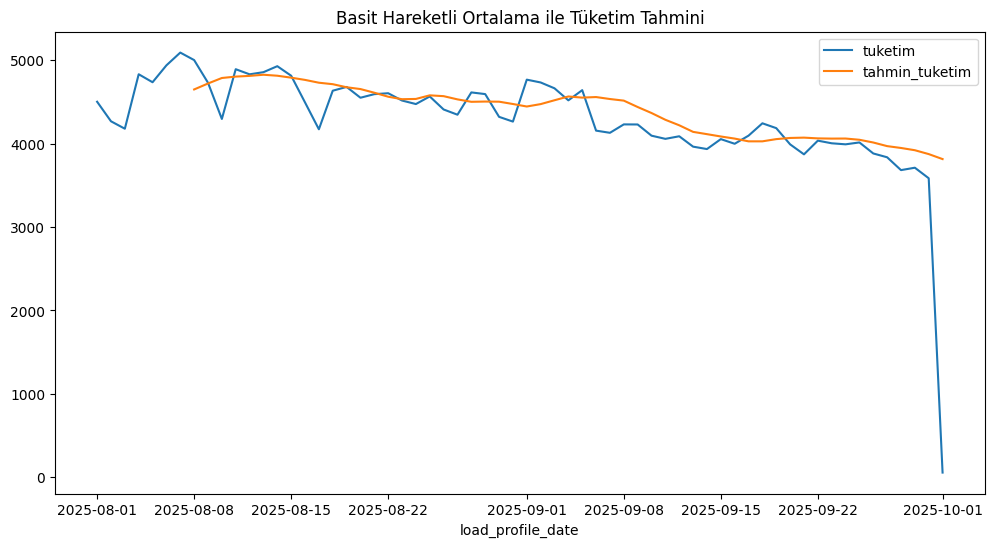

In [19]:
df['load_profile_date'] = pd.to_datetime(df['load_profile_date'])
daily_data = df.groupby(df['load_profile_date'].dt.date)['tuketim'].sum()

tahmin_df = daily_data.to_frame()
tahmin_df['tahmin_tuketim'] = tahmin_df['tuketim'].rolling(window=7).mean().shift(1)

tahmin_df.plot(figsize=(12,6), title="Basit Hareketli Ortalama ile Tüketim Tahmini")